# Colorimetry Figures
This notebook generates all figures for the colorimetry series:
- Figure 1.1: SPD Comparison (Tungsten vs. White LED)
- Figure 1.4: LMS Cone Spectral Sensitivities
- Figure 1.6: Camera Sensor vs Human Observer

## Figure 1.1: Spectral Power Distribution Comparison
### Continuous (Tungsten) vs. Discontinuous (White LED) Light Sources

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for character 0x0a in encoding latin1”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for character 0x0a in encoding latin1”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for character 0x0a in encoding latin1”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for character 0x0a in encoding latin1”


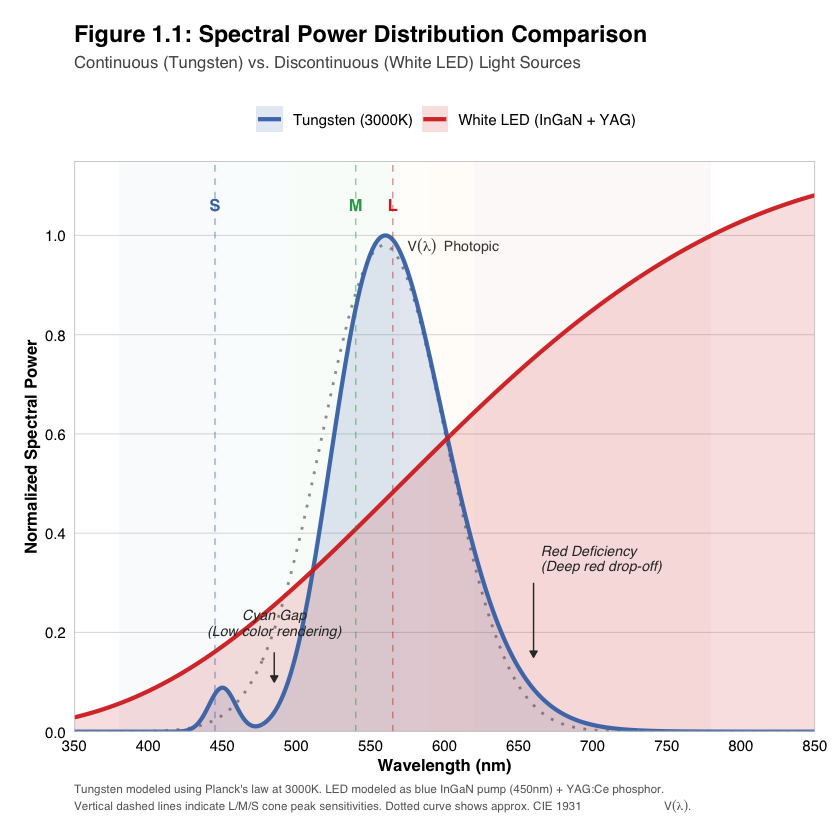

In [38]:
# ==============================================================================
# Figure 1.1: SPD Comparison - Tungsten vs. White LED
# Context: Continuous vs. Discontinuous Light Sources
# ==============================================================================

# 1. SETUP & LIBRARIES ---------------------------------------------------------
suppressPackageStartupMessages({
  library(ggplot2)
  library(dplyr)
  library(tidyr)
  library(scales) # For fancy formatting if needed
})

# 2. DEFINITIONS & CONSTANTS ---------------------------------------------------

# Strict Hex Color Palette (Preserved)
palette <- list(
  R = "#d73027",  # Red (Tungsten/L-Cone)
  G = "#31a354",  # Green (M-Cone)
  B = "#4575b4",  # Blue (LED/S-Cone)
  C = "#5ab4ac",  # Cyan
  M = "#c51b8a",  # Magenta
  Y_marker = "#F3CF6D" # Yellow marker
)

# Physics Constants
h <- 6.62607015e-34  # Planck constant (J*s)
c <- 2.99792458e8    # Speed of light (m/s)
k <- 1.380649e-23    # Boltzmann constant (J/K)

# 3. DATA GENERATION FUNCTIONS -------------------------------------------------

# A. Planck's Law Function (Tungsten)
# Returns spectral radiance as a function of wavelength (nm) and Temp (K)
planck_law <- function(wavelength_nm, temp_k) {
  w_m <- wavelength_nm * 1e-9  # Convert to meters
  p1 <- (2 * h * c^2) / (w_m^5)
  p2 <- 1 / (exp((h * c) / (w_m * k * temp_k)) - 1)
  return(p1 * p2)
}

# B. Photopic Sensitivity Approximation (CIE 1931 V_lambda)
# Using a skewed Gaussian approximation for smooth plotting
get_photopic <- function(wl) {
  # Peak ~555nm
  1.019 * exp(-285.4 * (wl * 1e-3 - 0.559)^2) 
}

# 4. DATA SIMULATION -----------------------------------------------------------

# Define range
wavelengths <- seq(350, 850, by = 1)

# -- Simulate Tungsten (3000K) --
# Note: 3000K peaks in IR (~966nm), so visible spectrum is the rising edge.
tungsten_raw <- planck_law(wavelengths, 3000)
# Normalize so the curve fits nicely on the chart (relative to visible max)
tungsten_norm <- tungsten_raw / max(tungsten_raw[wavelengths >= 380 & wavelengths <= 780])

# -- Simulate White LED (InGaN + YAG) --
# 1. Blue Pump: Sharp peak at 450nm (Gaussian)
blue_pump <- dnorm(wavelengths, mean = 450, sd = 9) 
# 2. Phosphor: Broad emission centered ~560nm (Gamma distribution)
# Shift wavelength to align gamma distribution correctly
x_shifted <- (wavelengths - 420) / 12
phosphor_raw <- dgamma(x_shifted, shape = 15, rate = 1.2)
phosphor_raw[is.na(phosphor_raw)] <- 0
# Normalize phosphor
phosphor_norm <- phosphor_raw / max(phosphor_raw)
# Combine: Weighted sum (Adjust weights to simulate Cool/Neutral White)
led_raw <- (blue_pump * 1.8) + (phosphor_norm * 0.9)
led_norm <- led_raw / max(led_raw)

# -- Combine into Main Data Frame --
spd_data <- data.frame(
  Wavelength = wavelengths, 
  Tungsten = tungsten_norm, 
  LED = led_norm
) %>% 
  pivot_longer(cols = c("Tungsten", "LED"), names_to = "Source", values_to = "Power")

# -- Photopic Curve Data --
photopic_data <- data.frame(
  Wavelength = wavelengths,
  Photopic = get_photopic(wavelengths)
) %>%
  mutate(Photopic = ifelse(Wavelength < 380 | Wavelength > 780, 0, Photopic)) %>%
  mutate(Photopic = Photopic / max(Photopic) * 0.98) # Scale to 0.98 for visual hierarchy

# -- Cone Peak Markers --
cone_peaks <- data.frame(
  Cone = c("S", "M", "L"), 
  Peak = c(445, 540, 565), 
  Color = c(palette$B, palette$G, palette$R)
)

# 5. PLOTTING ------------------------------------------------------------------

figure_1_1 <- ggplot() +
  
  # A. Background Spectral Bands (Visual Reference)
  annotate("rect", xmin = 380, xmax = 450, ymin = 0, ymax = 1.15, fill = palette$B, alpha = 0.03) +
  annotate("rect", xmin = 450, xmax = 495, ymin = 0, ymax = 1.15, fill = palette$C, alpha = 0.03) +
  annotate("rect", xmin = 495, xmax = 570, ymin = 0, ymax = 1.15, fill = palette$G, alpha = 0.03) +
  annotate("rect", xmin = 570, xmax = 590, ymin = 0, ymax = 1.15, fill = palette$Y_marker, alpha = 0.03) +
  annotate("rect", xmin = 590, xmax = 620, ymin = 0, ymax = 1.15, fill = "#ff8800", alpha = 0.03) +
  annotate("rect", xmin = 620, xmax = 780, ymin = 0, ymax = 1.15, fill = palette$R, alpha = 0.03) +

  # B. Photopic Sensitivity Curve (Bottom Layer)
  geom_line(data = photopic_data, aes(x = Wavelength, y = Photopic), 
            color = "#555555", linetype = "dotted", linewidth = 0.8, alpha = 0.6) +
  
  # C. Main SPD Curves (Area + Line)
  geom_area(data = spd_data, aes(x = Wavelength, y = Power, fill = Source), 
            position = "identity", alpha = 0.15) +
  geom_line(data = spd_data, aes(x = Wavelength, y = Power, color = Source), 
            linewidth = 1.2, alpha = 0.95) +
  
  # D. Cone Peak Indicators
  geom_vline(data = cone_peaks, aes(xintercept = Peak), 
             color = cone_peaks$Color, linetype = "dashed", linewidth = 0.4, alpha = 0.5) +
  geom_text(data = cone_peaks, aes(x = Peak, y = 1.05, label = Cone), 
            color = cone_peaks$Color, fontface = "bold", size = 3.5, vjust = 0) +

  # E. Scales & Colors (Strict Logic: Tungsten=Red, LED=Blue)
  scale_color_manual(
    values = c("Tungsten" = palette$R, "LED" = palette$B), 
    labels = c("Tungsten (3000K)", "White LED (InGaN + YAG)")
  ) +
  scale_fill_manual(
    values = c("Tungsten" = palette$R, "LED" = palette$B),
    labels = c("Tungsten (3000K)", "White LED (InGaN + YAG)")
  ) +

  # F. Annotations (Refined Positioning: Vertical Arrows)
  
  # 1. Cyan Gap (Valley between 450nm and 500nm)
  # Text moved to x=485 to align with arrow
  annotate("text", x = 485, y = 0.22, label = "Cyan Gap\n(Low color rendering)", 
           color = "#333333", size = 3.0, fontface = "italic", lineheight = 0.9, hjust = 0.5) +
  # Arrow is now vertical (x = 485, xend = 485)
  annotate("segment", x = 485, xend = 485, y = 0.16, yend = 0.10, 
           arrow = arrow(length = unit(0.15, "cm"), type = "closed"), color = "#333333", linewidth = 0.4) +
  
  # 2. Red Deficiency (Drop off > 650nm)
  # Text moved to x=665 to align near the vertical arrow
  annotate("text", x = 665, y = 0.35, label = "Red Deficiency\n(Deep red drop-off)", 
           color = "#333333", size = 3.0, fontface = "italic", lineheight = 0.9, hjust = 0) +
  # Arrow is now vertical (x = 660, xend = 660)
  annotate("segment", x = 660, xend = 660, y = 0.30, yend = 0.15, 
           arrow = arrow(length = unit(0.15, "cm"), type = "closed"), color = "#333333", linewidth = 0.4) +

  # 3. Photopic Label (Near 560nm Peak)
  annotate("text", x = 575, y = 0.98, label = expression(V(lambda)~~Photopic), 
           color = "#444444", size = 3.0, hjust = 0) +

  # G. Layout & Typography
  scale_x_continuous(breaks = seq(350, 850, by = 50), limits = c(350, 850), expand = c(0,0)) +
  scale_y_continuous(breaks = seq(0, 1.0, by = 0.2), limits = c(0, 1.15), expand = c(0, 0)) +
  
  labs(
    title = "Figure 1.1: Spectral Power Distribution Comparison", 
    subtitle = "Continuous (Tungsten) vs. Discontinuous (White LED) Light Sources", 
    x = "Wavelength (nm)", 
    y = "Normalized Spectral Power", 
    caption = expression(paste("Tungsten modeled using Planck's law at 3000K. LED modeled as blue InGaN pump (450nm) + YAG:Ce phosphor.\nVertical dashed lines indicate L/M/S cone peak sensitivities. Dotted curve shows approx. CIE 1931 ", V(lambda), "."))
  ) +
  
  theme_minimal(base_family = "sans", base_size = 11) +
  theme(
    plot.title = element_text(face = "bold", size = 14, margin = margin(b = 5)),
    plot.subtitle = element_text(size = 10, color = "#555555", margin = margin(b = 15)),
    plot.caption = element_text(size = 7, color = "#666666", hjust = 0, margin = margin(t = 15), lineheight = 1.2),
    legend.position = "top",
    legend.title = element_blank(),
    legend.text = element_text(size = 9),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    panel.grid.major.y = element_line(color = "#e0e0e0", linewidth = 0.3),
    panel.border = element_rect(color = "#cccccc", fill = NA, linewidth = 0.5),
    axis.title = element_text(face = "bold", size = 10),
    axis.text = element_text(color = "black", size = 9),
    plot.margin = margin(15, 15, 15, 15)
  )

# 6. OUTPUT --------------------------------------------------------------------
print(figure_1_1)

# Optional: Save commands (Uncomment paths as needed)
ggsave("fig-1-1.png", plot = figure_1_1, width = 10, height = 6, dpi = 300, bg = "white")
ggsave("fig-1-1.pdf", plot = figure_1_1, width = 10, height = 6, device = cairo_pdf)

## Figure 1.4: LMS Cone Spectral Sensitivities
### Human trichromatic color vision with significant L-M overlap

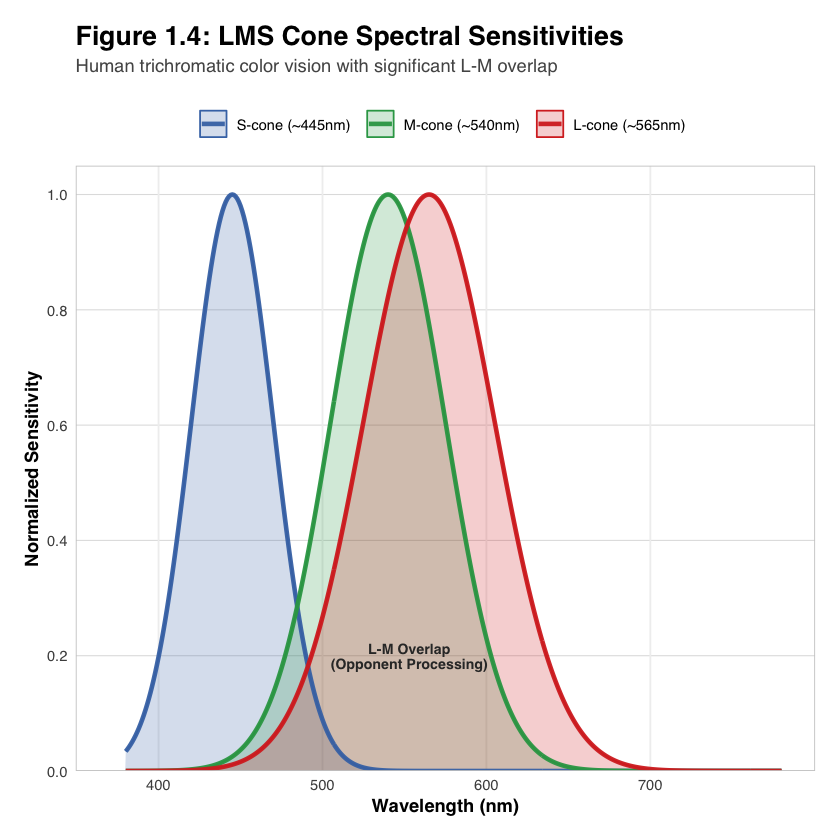

In [35]:
# ==============================================================================
# Figure 1.4: LMS Cone Spectral Sensitivities
# Improvement: Text moved directly into the overlap region (no arrow)
# ==============================================================================

# 1. SETUP ---------------------------------------------------------------------
suppressPackageStartupMessages({
  library(ggplot2)
  library(dplyr)
  library(tidyr)
})

# 2. DATA GENERATION -----------------------------------------------------------
# Visual constants
palette <- list(R = "#d73027", G = "#31a354", B = "#4575b4")
wavelengths <- seq(380, 780, by = 1)

# Generate Gaussian curves (Normalized)
s_cone <- dnorm(wavelengths, mean = 445, sd = 25)
m_cone <- dnorm(wavelengths, mean = 540, sd = 35)
l_cone <- dnorm(wavelengths, mean = 565, sd = 40)

# Normalize peaks to 1.0
s_cone <- s_cone / max(s_cone)
m_cone <- m_cone / max(m_cone)
l_cone <- l_cone / max(l_cone)

# Create tidy data frame for plotting
cone_data <- data.frame(Wavelength = wavelengths, S = s_cone, M = m_cone, L = l_cone) %>% 
  pivot_longer(cols = c("S", "M", "L"), names_to = "Cone", values_to = "Sensitivity")
cone_data$Cone <- factor(cone_data$Cone, levels = c("S", "M", "L"))

# 3. PLOTTING ------------------------------------------------------------------
figure_1_4 <- ggplot(cone_data, aes(x = Wavelength, y = Sensitivity, color = Cone)) +
  
  # Curves
  geom_area(aes(fill = Cone), position = "identity", alpha = 0.22) +
  geom_line(linewidth = 1.3, alpha = 0.95) +
  
  # Colors
  scale_color_manual(values = c(palette$B, palette$G, palette$R), 
                     labels = c("S-cone (~445nm)", "M-cone (~540nm)", "L-cone (~565nm)")) +
  scale_fill_manual(values = c(palette$B, palette$G, palette$R), 
                    labels = c("S-cone (~445nm)", "M-cone (~540nm)", "L-cone (~565nm)")) +
  
  # Annotation: Centered inside the overlap
  # Positioned at x=553 (mid-overlap) and y=0.5 (vertical center of the intersection area)
  annotate("text", x = 553, y = 0.2, label = "L-M Overlap\n(Opponent Processing)", 
           color = "#333333", size = 3.0, fontface = "bold", lineheight = 0.9, hjust = 0.5) +

  # Layout
  # Reset Y limit to 1.05 since we don't need the extra headroom anymore
  scale_y_continuous(breaks = seq(0, 1, 0.2), limits = c(0, 1.05), expand = c(0,0)) +
  scale_x_continuous(breaks = seq(400, 700, 100), limits = c(370, 780)) +
  
  labs(title = "Figure 1.4: LMS Cone Spectral Sensitivities", 
       subtitle = "Human trichromatic color vision with significant L-M overlap", 
       x = "Wavelength (nm)", y = "Normalized Sensitivity") +
  
  theme_minimal(base_family = "sans", base_size = 11) +
  theme(
    plot.title = element_text(face = "bold", size = 16, margin = margin(b = 5)),
    plot.subtitle = element_text(size = 11, color = "#555555", margin = margin(b = 15)),
    legend.position = "top",
    legend.title = element_blank(),
    panel.grid.major.y = element_line(color = "#e0e0e0", linewidth = 0.3),
    panel.grid.major.x = element_line(color = "#f0f0f0"), 
    panel.grid.minor = element_blank(),
    panel.border = element_rect(color = "#cccccc", fill = NA, linewidth = 0.5),
    axis.title = element_text(face = "bold", size = 11),
    plot.margin = margin(15, 15, 15, 15)
  )

# 4. OUTPUT --------------------------------------------------------------------
print(figure_1_4)

# Save
ggsave("../../../assets/figures/colorimetry/png/fig-1-4.png", plot = figure_1_4, width = 10, height = 6, dpi = 300, bg = "white")
device_func <- if (capabilities("cairo")) cairo_pdf else "pdf"
ggsave("../../../assets/figures/colorimetry/pdf/fig-1-4.pdf", plot = figure_1_4, width = 10, height = 6, device = device_func)

## Figure 1.6: Camera Sensor vs Human Observer
### The fundamental mismatch that ACES IDTs correct

Figures saved successfully.


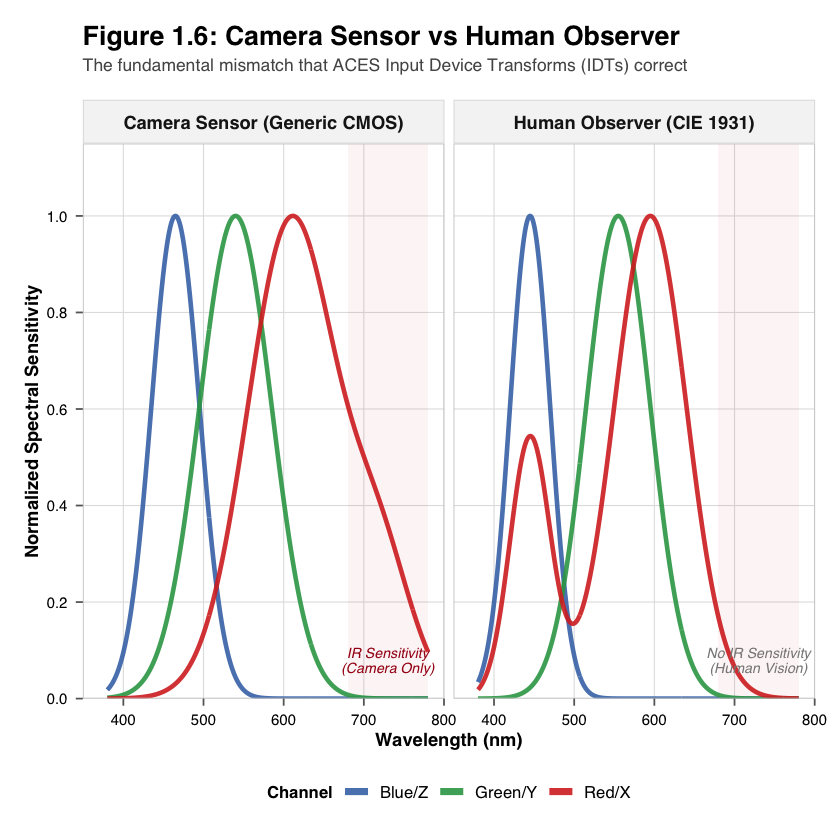

In [32]:
# ==============================================================================
# Figure 1.6: Camera Sensor vs Human Observer
# Improvement: Fixed Legend Conflict (Clean Manual Coloring)
# ==============================================================================

# 1. SETUP & LIBRARIES ---------------------------------------------------------
suppressPackageStartupMessages({
  library(ggplot2)
  library(dplyr)
  library(tidyr)
})

# 2. DATA GENERATION -----------------------------------------------------------

# Scientific color palette
palette <- list(
  R = "#d73027", 
  G = "#31a354", 
  B = "#4575b4"
)

# Wavelength range
wavelengths <- seq(380, 780, by = 1)

# -- Human Observer (CIE 1931 approximations) --
cie_x <- dnorm(wavelengths, mean = 595, sd = 45) * 1.0 + dnorm(wavelengths, mean = 445, sd = 25) * 0.3
cie_y <- dnorm(wavelengths, mean = 555, sd = 40)
cie_z <- dnorm(wavelengths, mean = 445, sd = 25)

# Normalize
cie_x <- cie_x / max(cie_x)
cie_y <- cie_y / max(cie_y)
cie_z <- cie_z / max(cie_z)

# -- Camera sensor (Generic CMOS approximations) --
# Note: Added slight bump at 720nm to simulate IR sensitivity leak
cam_r <- dnorm(wavelengths, mean = 610, sd = 55) + dnorm(wavelengths, mean = 720, sd = 40) * 0.2
cam_g <- dnorm(wavelengths, mean = 540, sd = 45)
cam_b <- dnorm(wavelengths, mean = 465, sd = 30)

# Normalize
cam_r <- cam_r / max(cam_r)
cam_g <- cam_g / max(cam_g)
cam_b <- cam_b / max(cam_b)

# -- Combine into Main Data Frame --
observer_data <- data.frame(
  Wavelength = wavelengths, 
  CIE_X = cie_x, CIE_Y = cie_y, CIE_Z = cie_z, 
  Camera_R = cam_r, Camera_G = cam_g, Camera_B = cam_b
) %>% 
  pivot_longer(cols = c("CIE_X", "CIE_Y", "CIE_Z", "Camera_R", "Camera_G", "Camera_B"), 
               names_to = "Channel", values_to = "Sensitivity") %>% 
  mutate(
    Type = ifelse(grepl("CIE", Channel), "Human Observer (CIE 1931)", "Camera Sensor (Generic CMOS)"),
    Color = case_when(
      Channel %in% c("CIE_X", "Camera_R") ~ "Red/X",
      Channel %in% c("CIE_Y", "Camera_G") ~ "Green/Y",
      Channel %in% c("CIE_Z", "Camera_B") ~ "Blue/Z"
    )
  )

# -- Annotation Data --
# We separate these to control color manually without affecting the main legend
anno_camera <- data.frame(
  Type = "Camera Sensor (Generic CMOS)", 
  xmin = 680, xmax = 780,
  ymin = 0, ymax = 1.15,
  label = "IR Sensitivity\n(Camera Only)"
)

anno_human <- data.frame(
  Type = "Human Observer (CIE 1931)", 
  xmin = 680, xmax = 780,
  ymin = 0, ymax = 1.15,
  label = "No IR Sensitivity\n(Human Vision)"
)

# 3. PLOTTING ------------------------------------------------------------------

figure_1_6 <- ggplot(observer_data, aes(x = Wavelength, y = Sensitivity)) +
  
  # A. IR Region Highlight (Vertical Band on Both Facets)
  geom_rect(data = rbind(anno_camera, anno_human), 
            aes(xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax),
            fill = palette$R, alpha = 0.05, inherit.aes = FALSE) + 

  # B. Main Curves
  geom_line(aes(color = Color, linetype = Type), linewidth = 1.3, alpha = 0.9) +
  
  # C. Annotations (Split layers to fix Legend bug)
  # Layer 1: Camera (Red Text)
  geom_text(data = anno_camera, 
            aes(x = 730, y = 0.08, label = label), 
            color = "#a50f15", size = 3.0, fontface = "italic", lineheight = 0.9, inherit.aes = FALSE) +
  
  # Layer 2: Human (Gray Text)
  geom_text(data = anno_human, 
            aes(x = 730, y = 0.08, label = label), 
            color = "#888888", size = 3.0, fontface = "italic", lineheight = 0.9, inherit.aes = FALSE) +
  
  # D. Faceting
  facet_wrap(~Type, ncol = 2) +
  
  # E. Colors & Styles
  # Now this scale only manages the 3 main curve colors, preserving the legend
  scale_color_manual(values = c("Blue/Z" = palette$B, "Green/Y" = palette$G, "Red/X" = palette$R)) +
  scale_linetype_manual(values = c("Human Observer (CIE 1931)" = "solid", "Camera Sensor (Generic CMOS)" = "solid")) +
  
  # F. Layout & Labels
  labs(
    title = "Figure 1.6: Camera Sensor vs Human Observer", 
    subtitle = "The fundamental mismatch that ACES Input Device Transforms (IDTs) correct", 
    x = "Wavelength (nm)", 
    y = "Normalized Spectral Sensitivity", 
    color = "Channel", 
    linetype = "Observer Type"
  ) +
  
  scale_y_continuous(breaks = seq(0, 1, 0.2), limits = c(0, 1.15), expand = c(0,0)) +
  scale_x_continuous(limits = c(370, 780)) +
  
  theme_minimal(base_family = "sans", base_size = 11) +
  theme(
    plot.title = element_text(face = "bold", size = 16, margin = margin(b = 5)),
    plot.subtitle = element_text(size = 10.5, color = "#555555", margin = margin(b = 15)),
    legend.position = "bottom",
    legend.box = "horizontal",
    legend.title = element_text(size = 10, face = "bold"),
    legend.text = element_text(size = 10),
    strip.text = element_text(size = 11, face = "bold", margin = margin(b = 8, t = 8)),
    strip.background = element_rect(fill = "#f5f5f5", color = "#dddddd", linewidth = 0.5),
    panel.grid.major = element_line(color = "#e0e0e0", linewidth = 0.3),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(color = "#cccccc", fill = NA, linewidth = 0.5),
    axis.title = element_text(face = "bold", size = 11),
    axis.text = element_text(color = "black", size = 9),
    axis.ticks = element_line(color = "#666666"),
    axis.ticks.length = unit(0.15, "cm"),
    plot.margin = margin(15, 15, 15, 15)
  ) +
  # Hide linetype legend, fix linewidth in color legend
  guides(linetype = "none", color = guide_legend(override.aes = list(linewidth = 2)))

# 4. OUTPUT --------------------------------------------------------------------
print(figure_1_6)

# Save Outputs
ggsave("../../../assets/figures/colorimetry/png/fig-1-6.png", 
       plot = figure_1_6, width = 10, height = 6.5, dpi = 300, bg = "white")

device_func <- if (capabilities("cairo")) cairo_pdf else "pdf"
ggsave("../../../assets/figures/colorimetry/pdf/fig-1-6.pdf", 
       plot = figure_1_6, width = 10, height = 6.5, device = device_func)

cat("Figures saved successfully.\n")